In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
with open("SMSSpamCollection.csv", "r", encoding="utf-8", errors="replace") as f:
    lines = f.read().splitlines()

rows = [line.split("\t", 1) for line in lines]

data = pd.DataFrame(rows, columns=["label", "message"])

data["label"] = data["label"].str.strip('"')
data["message"] = data["message"].str.strip('"')

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("Shape:", data.shape)

print("Columns:")
print(data.columns)

print("Missing values:")
print(data.isnull().sum())

print("Class distribution:")
print(data["label"].value_counts())

Shape: (5574, 2)
Columns:
Index(['label', 'message'], dtype='object')
Missing values:
label      0
message    0
dtype: int64
Class distribution:
label
ham     4827
spam     747
Name: count, dtype: int64


In [ ]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 414


In [ ]:
data = data.drop_duplicates().reset_index(drop=True)

print(data.shape)

(5160, 2)


In [ ]:
data["label_num"] = data["label"].map({
    "ham": 0,
    "spam": 1
})

In [ ]:
class_counts = data["label"].value_counts()

print(class_counts)

label
ham     4518
spam     642
Name: count, dtype: int64


In [ ]:
class_percent = data["label"].value_counts(normalize=True) * 100

print(class_percent)

label
ham     87.55814
spam    12.44186
Name: proportion, dtype: float64


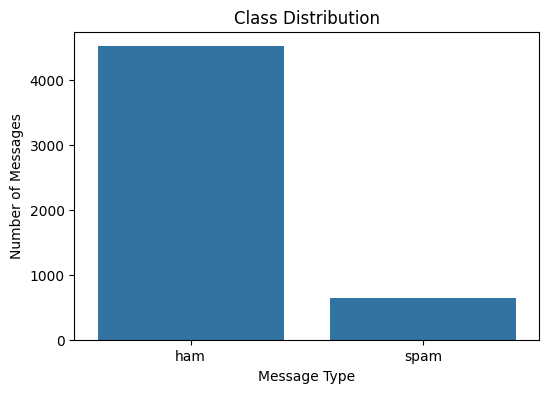

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x="label"
)

plt.title("Class Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [ ]:
data["message_length"] = data["message"].str.len()

In [ ]:
print(data.groupby("label")["message_length"].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4518.0   70.870739  56.619245   2.0   34.0   53.0   91.0  910.0
spam    642.0  137.434579  29.967839  13.0  131.0  148.0  157.0  223.0


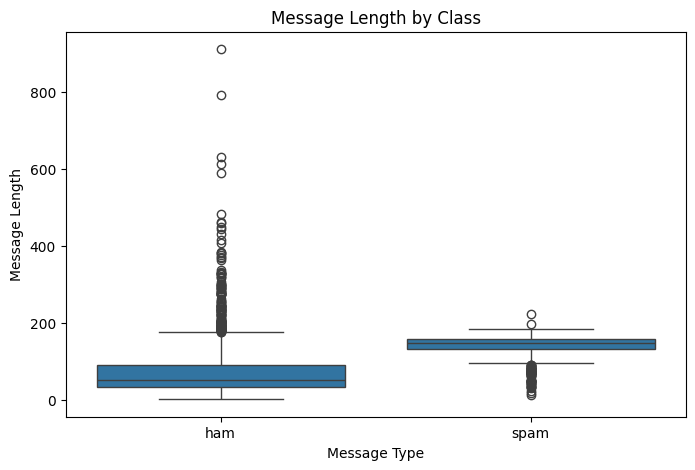

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="label",
    y="message_length"
)

plt.title("Message Length by Class")
plt.xlabel("Message Type")
plt.ylabel("Message Length")

plt.show()

In [ ]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Return cleaned text
    return " ".join(tokens)

In [ ]:
data["clean_message"] = data["message"].apply(preprocess_text)

In [ ]:
X = data["clean_message"]
y = data["label_num"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
count_vectorizer = CountVectorizer(
    ngram_range=(1, 1)
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

In [ ]:
count_vectorizer_bigram = CountVectorizer(
    ngram_range=(1, 2)
)

X_train_count_bigram = count_vectorizer_bigram.fit_transform(X_train)

X_test_count_bigram = count_vectorizer_bigram.transform(X_test)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
tfidf_vectorizer_bigram = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_train_tfidf_bigram = tfidf_vectorizer_bigram.fit_transform(X_train)

X_test_tfidf_bigram = tfidf_vectorizer_bigram.transform(X_test)

In [ ]:
model = MultinomialNB(alpha=1)

model.fit(
    X_train_count,
    y_train
)

MultinomialNB(alpha=1)

In [ ]:
alphas = [0.1, 0.5, 1, 2, 5]
feature_sets = {
    "CountVectorizer-Unigram": (
        X_train_count,
        X_test_count
    ),

    "CountVectorizer-Bigram": (
        X_train_count_bigram,
        X_test_count_bigram
    ),

    "TFIDF-Unigram": (
        X_train_tfidf,
        X_test_tfidf
    ),

    "TFIDF-Bigram": (
        X_train_tfidf_bigram,
        X_test_tfidf_bigram
    )
}

In [ ]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return accuracy, precision, recall, f1, roc_auc

In [ ]:
results = []

for feature_name, (Xtr, Xte) in feature_sets.items():

    for alpha in alphas:

        model = MultinomialNB(alpha=alpha)

        model.fit(Xtr, y_train)

        y_pred = model.predict(Xte)
        y_prob = model.predict_proba(Xte)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        cm = confusion_matrix(y_test, y_pred)

        tn, fp, fn, tp = cm.ravel()

        results.append({
            "Feature": feature_name,
            "Alpha": alpha,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC-AUC": roc_auc,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

In [ ]:
results_df = pd.DataFrame(results)

results_df

,Feature,Alpha,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
0,CountVectorizer-Unigram,0.1,0.976744,0.906250,0.906250,0.906250,0.978948,892,12,12,116
1,CountVectorizer-Unigram,0.5,0.977713,0.920000,0.898438,0.909091,0.975128,894,10,13,115
2,CountVectorizer-Unigram,1.0,0.979651,0.934959,0.898438,0.916335,0.969519,896,8,13,115
3,CountVectorizer-Unigram,2.0,0.978682,0.941667,0.882812,0.911290,0.960877,897,7,15,113
4,CountVectorizer-Unigram,5.0,0.971899,0.954128,0.812500,0.877637,0.947404,899,5,24,104
5,CountVectorizer-Bigram,0.1,0.977713,0.920000,0.898438,0.909091,0.978360,894,10,13,115
6,CountVectorizer-Bigram,0.5,0.978682,0.934426,0.890625,0.912000,0.970167,896,8,14,114
7,CountVectorizer-Bigram,1.0,0.978682,0.941667,0.882812,0.911290,0.961931,897,7,15,113
8,CountVectorizer-Bigram,2.0,0.977713,0.956522,0.859375,0.905350,0.952771,899,5,18,110
9,CountVectorizer-Bigram,5.0,0.972868,0.962963,0.812500,0.881356,0.941173,900,4,24,104


In [ ]:
results_df.sort_values(
    by="F1-Score",
    ascending=False
)

,Feature,Alpha,Accuracy,Precision,Recall,F1-Score,ROC-AUC
15,TFIDF-Bigram,0.1,0.982558,0.982456,0.875000,0.925620,0.985343
2,CountVectorizer-Unigram,1.0,0.979651,0.934959,0.898438,0.916335,0.969519
10,TFIDF-Unigram,0.1,0.979651,0.949580,0.882812,0.914980,0.986138
6,CountVectorizer-Bigram,0.5,0.978682,0.934426,0.890625,0.912000,0.970167
3,CountVectorizer-Unigram,2.0,0.978682,0.941667,0.882812,0.911290,0.960877
7,CountVectorizer-Bigram,1.0,0.978682,0.941667,0.882812,0.911290,0.961931
5,CountVectorizer-Bigram,0.1,0.977713,0.920000,0.898438,0.909091,0.978360
1,CountVectorizer-Unigram,0.5,0.977713,0.920000,0.898438,0.909091,0.975128
0,CountVectorizer-Unigram,0.1,0.976744,0.906250,0.906250,0.906250,0.978948
8,CountVectorizer-Bigram,2.0,0.977713,0.956522,0.859375,0.905350,0.952771


In [ ]:
best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print(best_model)

Feature      TFIDF-Bigram
Alpha                 0.1
Accuracy         0.982558
Precision        0.982456
Recall              0.875
F1-Score          0.92562
ROC-AUC          0.985343
Name: 15, dtype: object


In [ ]:
best_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_train_best = best_vectorizer.fit_transform(X_train)
X_test_best = best_vectorizer.transform(X_test)

best_nb = MultinomialNB(alpha=0.1)

best_nb.fit(
    X_train_best,
    y_train
)

y_pred_best = best_nb.predict(X_test_best)

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

print(cm)

[[902   2]
 [ 16 112]]


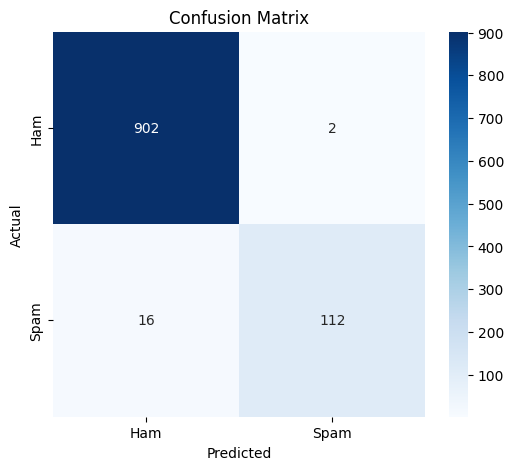

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       904
        Spam       0.99      0.75      0.85       128

    accuracy                           0.97      1032
   macro avg       0.98      0.87      0.92      1032
weighted avg       0.97      0.97      0.97      1032



In [ ]:
y_prob_best = best_nb.predict_proba(X_test_best)[:, 1]

auc = roc_auc_score(
    y_test,
    y_prob_best
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9730883573008849
